In [74]:
import numpy as np
import batman
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

G = 6.67430e-11
M_sun = 1.989e30
R_sun = 6.957e8

In [95]:


class Transit:

    def __init__(self, planet, star):

        self.planet_radius = planet.radius
        self.star_radius = star.radius
        self.planet_orbital_period = planet.orbital_period

        self.star_mass = star.mass

        # --- Newton Kepler 3rd law ---
        P = self.planet_orbital_period * 86400   # days -> seconds
        M = self.star_mass * M_sun              # solar masses -> kg

        self.semimajor_axis = (
            G * M * P**2 / (4 * np.pi**2)
        ) ** (1/3)                              #units of meters


        self.star_radius_m = self.star_radius * R_sun              # solar radii -> meters

        # convert to stellar radii for plotting + batman
        self.semimajor_axis = self.semimajor_axis / self.star_radius_m


    def make_lightcurve(self):
        params = batman.TransitParams()
        params.t0 = 50.                       #time of inferior conjunction
        params.per = self.planet_orbital_period                      #orbital period
        params.rp = self.planet_radius / self.star_radius     #planet radius (in units of stellar radii)
        params.a = self.semimajor_axis          #semi-major axis (in units of stellar radii)
        params.inc = 90.                     #orbital inclination (in degrees)
        params.ecc = 0.                      #eccentricity
        params.w = 90.                       #longitude of periastron (in degrees)
        params.u = [0.1, 0.3]                #limb darkening coefficients [u1, u2]
        params.limb_dark = "quadratic"       #limb darkening model
        t = np.linspace(0,100, 1000)            #times at which to calculate light curve)
        m = batman.TransitModel(params, t)    #initializes model
        flux = m.light_curve(params)          #calculates light curve

        plt.plot(t, flux)
        plt.xlabel("Time from central transit")
        plt.ylabel("Relative flux")
        plt.show()


    def make_snapshot(self, x):
        star_circle=plt.Circle((0,0),self.star_radius, color='yellow', alpha=1)
        planet_circle = plt.Circle((x,0),
                self.planet_radius,
                color='blue',
                alpha=1
            )

        fig, ax = plt.subplots()
        ax.add_patch(star_circle)
        ax.add_patch(planet_circle)
        plt.xlim(-2, 2)
        plt.ylim(-2, 2)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.hlines(0, -2, 2, color='black', linestyle='--', lw=0.5)
        plt.show()

    def make_animation(self):

        times = np.linspace(
            0,
            self.planet_orbital_period,
            100
        )

        fig, ax = plt.subplots()

        # star
        star_circle = plt.Circle(
            (0, 0),
            self.star_radius,
            color='yellow'
        )

        # planet
        planet_circle = plt.Circle(
            (0, 0),
            self.planet_radius,
            color='blue'
        )

        ax.add_patch(star_circle)
        ax.add_patch(planet_circle)

        ax.set_xlim(-1.2*self.semimajor_axis, 1.2*self.semimajor_axis)
        ax.set_ylim(-1.2*self.semimajor_axis, 1.2*self.semimajor_axis)
        ax.set_aspect('equal')

        def update(frame):

            t = times[frame]
            phase = 2*np.pi*t/self.planet_orbital_period

            x = self.semimajor_axis * np.sin(phase)

            planet_circle.center = (x, 0)

            return (planet_circle,)

        anim = FuncAnimation(
            fig,
            update,
            frames=len(times),
            interval=50,
            blit=True
        )

        plt.close(fig)  # prevents duplicate static plot

        return HTML(anim.to_jshtml())


    

class Planet:

    def __init__(self, radius, orbital_period):
        self.radius = radius
        self.orbital_period = orbital_period
        self.x = 0

class Star:

    def __init__(self, radius, mass):
        self.radius = radius
        self.mass = mass


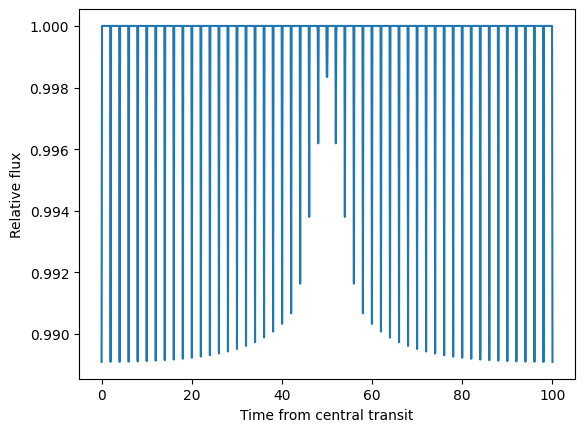

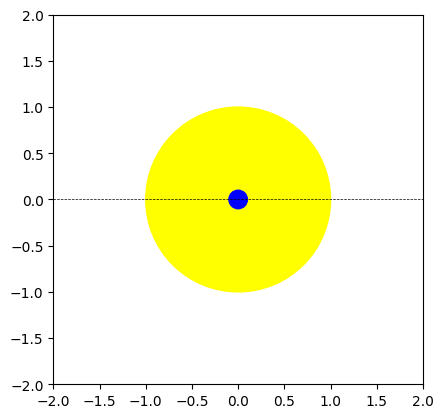

In [97]:
planet1 = Planet(radius=.10, orbital_period=2)  # Example planet with radius 1.0 and orbital period 365 days
star1 = Star(radius=1, mass=1)  # Example star with radius 1.0 and mass 1.0 solar units

transit1 = Transit(planet1, star1)
transit1.make_lightcurve()
transit1.make_snapshot(0)
transit1.make_animation()